In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the data
df = pd.read_csv('E:\Covid 19 data set.csv')

# Data Information
print(df.shape)
print(df.head())
print(df.info())

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\khan\AppData\Local\Temp\ipykernel_266104\3473032282.py:2: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv('E:\Covid 19 data set.csv')


(44785, 41)
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  12/31/2019          0.0        0.0   
1      AFG      Asia  Afghanistan    1/1/2020          0.0        0.0   
2      AFG      Asia  Afghanistan    1/2/2020          0.0        0.0   
3      AFG      Asia  Afghanistan    1/3/2020          0.0        0.0   
4      AFG      Asia  Afghanistan    1/4/2020          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   gdp_per_capita  extreme_poverty  cardiovasc_death_rate  \
0        1803.987        

In [8]:
# column names
print(df.columns.tolist())

# Check missing values
print(df.isnull().sum())

# Check data types
print(df.dtypes)

['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'new_tests', 'total_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'tests_per_case', 'positive_rate', 'tests_units', 'stringency_index', 'population', 'population_density', 'median_age', 'aged_65_older', 'aged_70_older', 'gdp_per_capita', 'extreme_poverty', 'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers', 'male_smokers', 'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index']
iso_code                             264
continent                            528
location                               0
date                                   

In [12]:
# Fill missing values with median for numeric columns
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill continent with 'Unknown' (it's text)
df['continent'].fillna('Unknown', inplace=True)

# Verify - should show 0 or very low missing values now
print(df.isnull().sum())

iso_code                           264
continent                            0
location                             0
date                                 0
total_cases                          0
new_cases                            0
new_cases_smoothed                   0
total_deaths                         0
new_deaths                           0
new_deaths_smoothed                  0
total_cases_per_million              0
new_cases_per_million                0
new_cases_smoothed_per_million       0
total_deaths_per_million             0
new_deaths_per_million               0
new_deaths_smoothed_per_million      0
stringency_index                     0
population                           0
population_density                   0
median_age                           0
aged_65_older                        0
aged_70_older                        0
gdp_per_capita                       0
cardiovasc_death_rate                0
diabetes_prevalence                  0
hospital_beds_per_thousan

C:\Users\khan\AppData\Local\Temp\ipykernel_266104\1672196568.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\khan\AppData\Local\Temp\ipykernel_266104\1672196568.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [13]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Verify
print(df['date'].dtype)
print(df['date'].min(), "to", df['date'].max())

datetime64[ns]
2019-12-31 00:00:00 to 2020-09-19 00:00:00


### Total COVID cases over time (Top 5 countries):

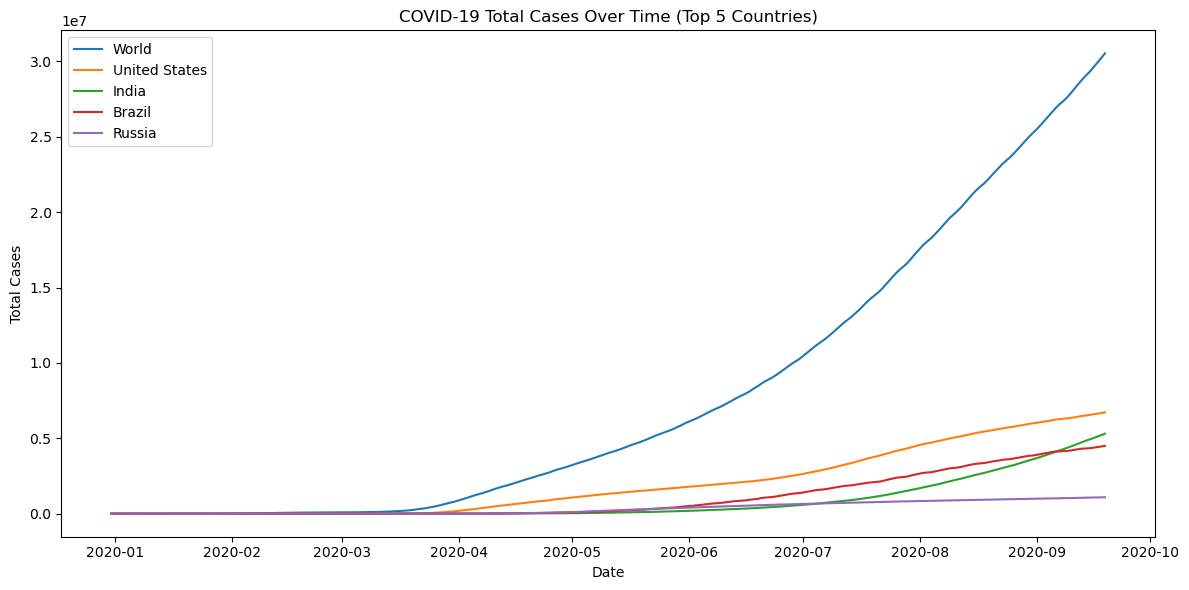

In [14]:
# Pick top 5 countries by total cases
top5 = df.groupby('location')['total_cases'].max().nlargest(5).index

# Filter data
df_top5 = df[df['location'].isin(top5)]

# Plot
plt.figure(figsize=(12,6))
for country in top5:
    data = df_top5[df_top5['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.title('COVID-19 Total Cases Over Time (Top 5 Countries)')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.tight_layout()
plt.show()

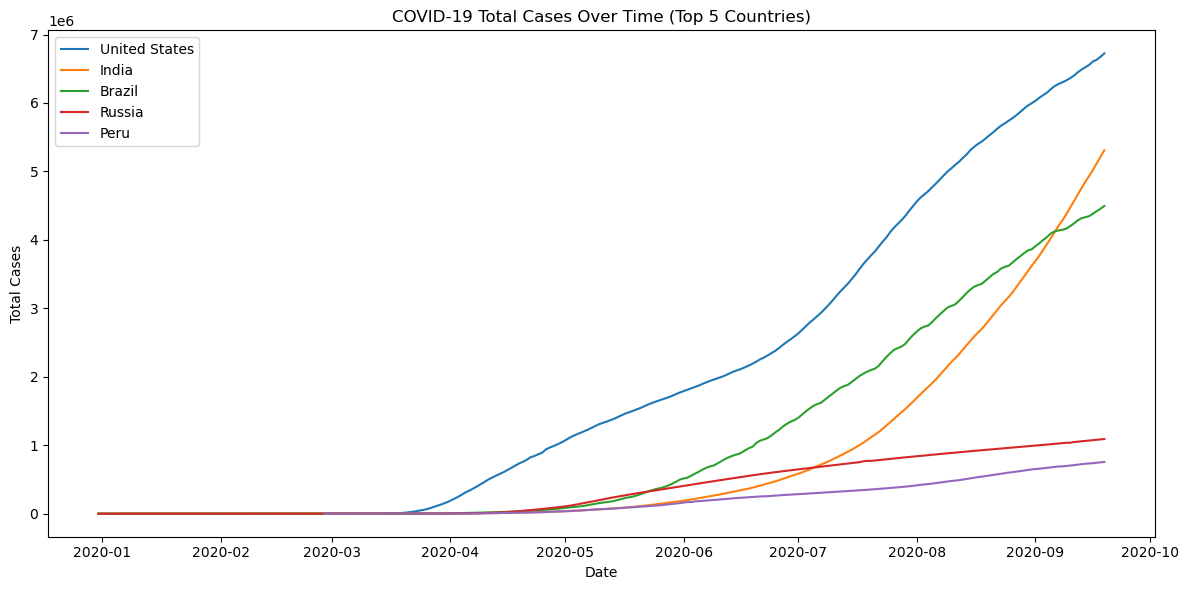

In [15]:
# Remove aggregated locations
exclude = ['World', 'Europe', 'Asia', 'Africa', 'North America', 
           'South America', 'Oceania', 'European Union']

df_countries = df[~df['location'].isin(exclude)]

# Now pick top 5 real countries
top5 = df_countries.groupby('location')['total_cases'].max().nlargest(5).index

# Filter data
df_top5 = df_countries[df_countries['location'].isin(top5)]

# Plot again after removing world
plt.figure(figsize=(12,6))
for country in top5:
    data = df_top5[df_top5['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.title('COVID-19 Total Cases Over Time (Top 5 Countries)')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.tight_layout()
plt.show()

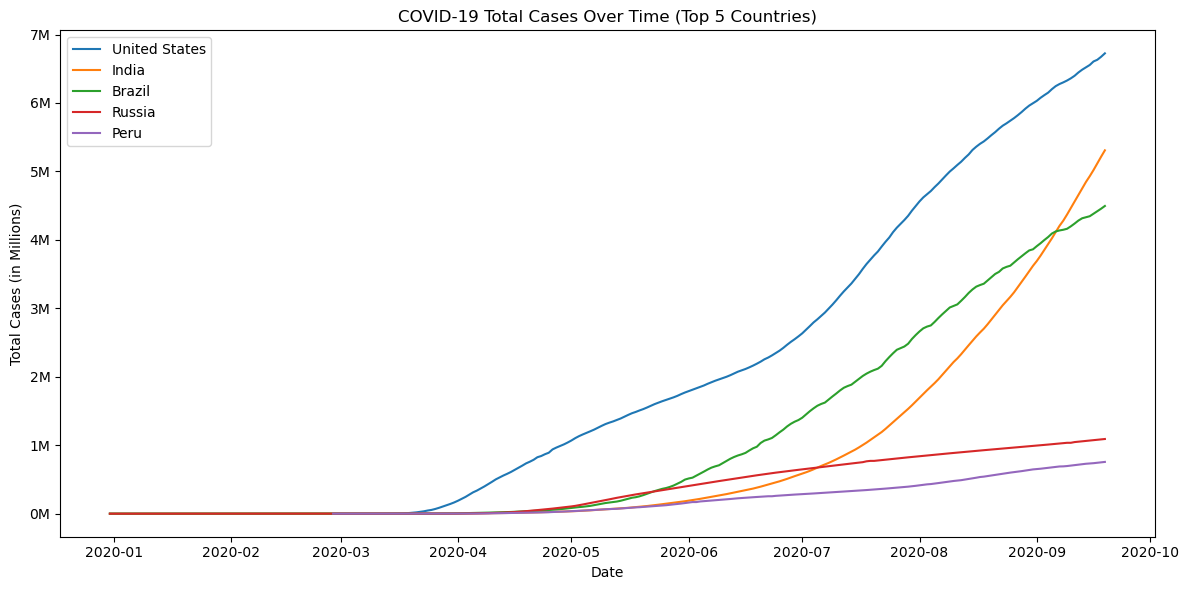

In [17]:
plt.figure(figsize=(12,6))
for country in top5:
    data = df_top5[df_top5['location'] == country]
    plt.plot(data['date'], data['total_cases'], label=country)

plt.title('COVID-19 Total Cases Over Time (Top 5 Countries)')
plt.xlabel('Date')
plt.ylabel('Total Cases (in Millions)')
plt.legend()

# Shows values in millions like 5M, 10M, 50M
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

plt.tight_layout()
plt.show()

### Daily New Cases (Top 5 Countries):

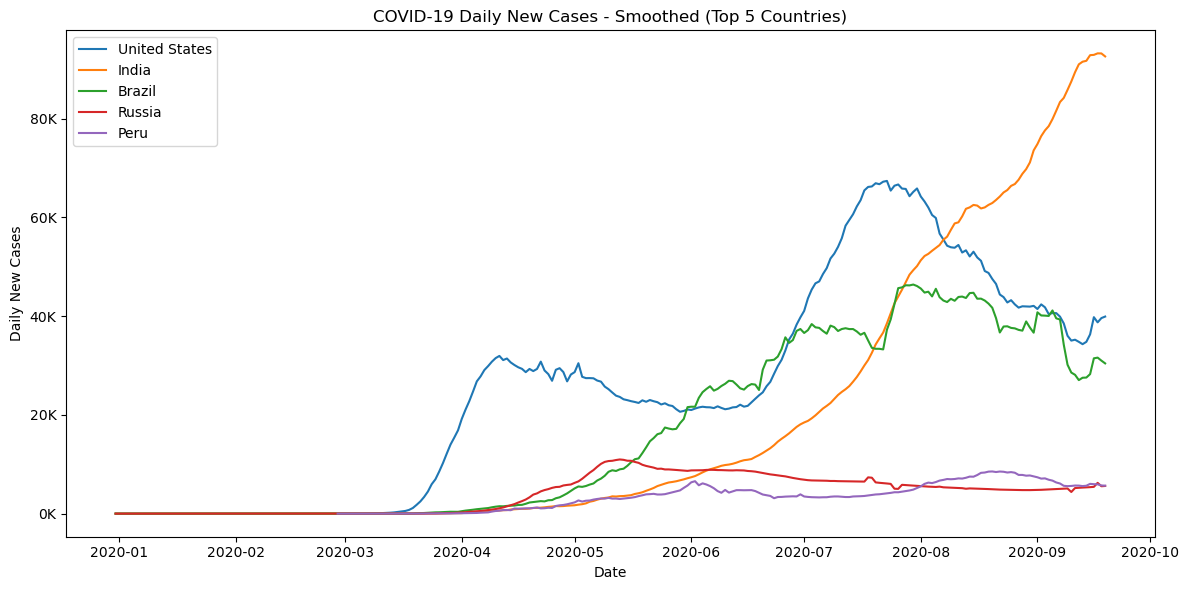

In [18]:
plt.figure(figsize=(12,6))
for country in top5:
    data = df_top5[df_top5['location'] == country]
    plt.plot(data['date'], data['new_cases_smoothed'], label=country)

plt.title('COVID-19 Daily New Cases - Smoothed (Top 5 Countries)')
plt.xlabel('Date')
plt.ylabel('Daily New Cases')
plt.legend()

# Y axis in thousands
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)

plt.tight_layout()
plt.show()

### Total Deaths by Continent (Bar Chart):

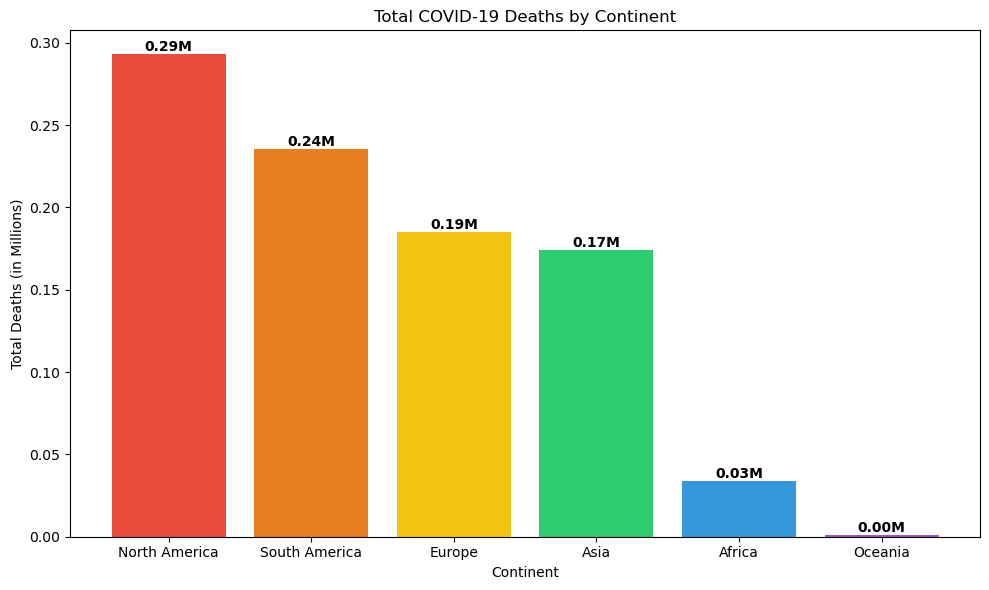

In [19]:
# Get latest data per country and remove aggregated locations
df_latest = df_countries[df_countries['date'] == df_countries['date'].max()]

# Group by continent
continent_deaths = df_latest.groupby('continent')['total_deaths'].sum().sort_values(ascending=False)

# Remove 'Unknown' continent
continent_deaths = continent_deaths[continent_deaths.index != 'Unknown']

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(continent_deaths.index, continent_deaths.values/1_000_000, 
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6'])

plt.title('Total COVID-19 Deaths by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Deaths (in Millions)')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

###  Death Rate by Country (Top 10):

C:\Users\khan\AppData\Local\Temp\ipykernel_266104\85401938.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_latest['death_rate'] = (df_latest['total_deaths'] / df_latest['total_cases']) * 100


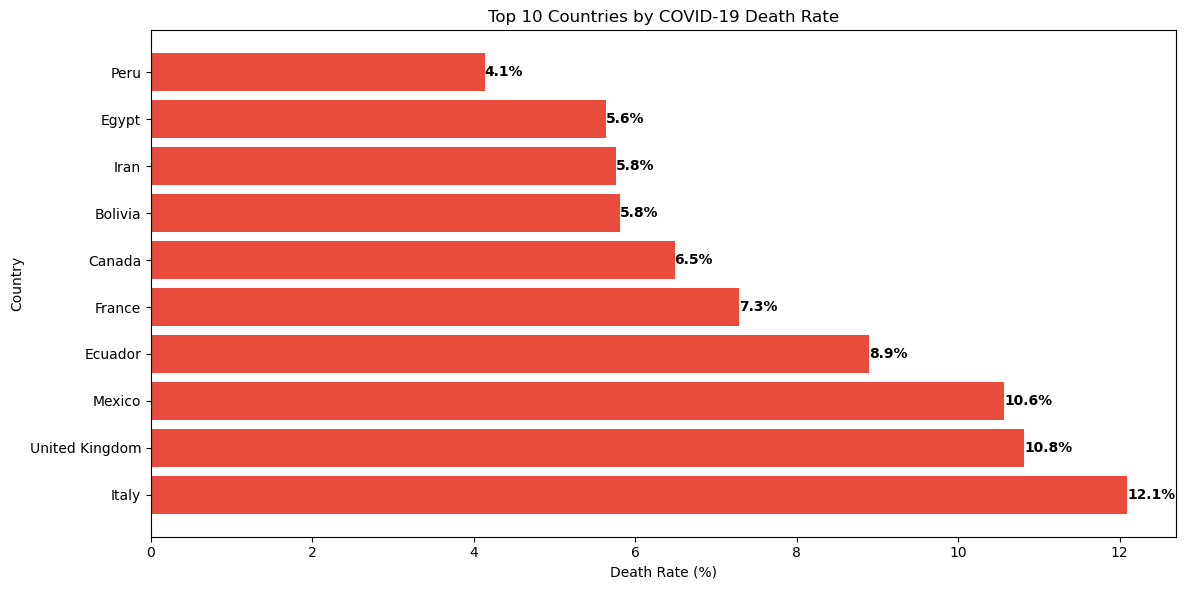

In [20]:
# Calculate death rate
df_latest['death_rate'] = (df_latest['total_deaths'] / df_latest['total_cases']) * 100

# Top 10 countries by death rate (minimum 100k cases to be meaningful)
df_meaningful = df_latest[df_latest['total_cases'] > 100000]
top10_death_rate = df_meaningful.nlargest(10, 'death_rate')[['location', 'death_rate']]

# Plot
plt.figure(figsize=(12,6))
bars = plt.barh(top10_death_rate['location'], top10_death_rate['death_rate'],
                color='#e74c3c')

plt.title('Top 10 Countries by COVID-19 Death Rate')
plt.xlabel('Death Rate (%)')
plt.ylabel('Country')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f'{width:.1f}%', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Export cleaned dataframe to Excel
df_countries.to_excel('covid19_cleaned.xlsx', index=False)
print("Exported successfully!")

Exported successfully!


In [25]:
import os
print(os.getcwd())

C:\Users\khan


In [26]:
import os
print(os.getcwd())


C:\Users\khan


In [27]:
import os
files = os.listdir(os.getcwd())
for f in files:
    print(f)
    

.anaconda
.chembl_ws_client__0.10.9
.conda
.condarc
.continuum
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
1. project.ipynb
3D Objects
AppData
Application Data
Contacts
Cookies
Desktop
Documents
Downloads
Drug Discovery .ipynb
Favorites
Links
Local Settings
Music
My Documents
NetHood
New.ipynb
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{fbfb8953-472f-11f0-9b28-18dbf20efb9d}.TxR.0.regtrans-ms
NTUSER.DAT{fbfb8953-472f-11f0-9b28-18dbf20efb9d}.TxR.1.regtrans-ms
NTUSER.DAT{fbfb8953-472f-11f0-9b28-18dbf20efb9d}.TxR.2.regtrans-ms
NTUSER.DAT{fbfb8953-472f-11f0-9b28-18dbf20efb9d}.TxR.blf
NTUSER.DAT{fbfb8954-472f-11f0-9b28-18dbf20efb9d}.TM.blf
NTUSER.DAT{fbfb8954-472f-11f0-9b28-18dbf20efb9d}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{fbfb8954-472f-11f0-9b28-18dbf20efb9d}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
PCAppStore
Pictures
PrintHood
Project 1.ipynb
Recent
Sample .ipynb
Saved Games
Searches
SendTo
Start Menu
Templates
Titanic.ipynb
Untitle